# Decision Tree - Model Development Workflow

> **MLCourse · Machine Learning · supervised · classification**

Production-style development on REAL penguin data: preprocessing, depth/pruning
tuning with CV, feature importances, and decision-surface reading.

## What you'll learn
- Clean end-to-end Pipeline for trees (scaler optional - trees don't care!)
- Tuning `max_depth` / `min_samples_leaf` / `ccp_alpha`
- `feature_importances_` interpretation & caveats
- Cost-complexity pruning path

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    pen = sns.load_dataset("penguins").dropna()
except Exception as e:
    print("offline?", e); raise

y = pen["species"]
X = pd.get_dummies(pen.drop(columns=["species"]),
                   columns=["island", "sex"], drop_first=True)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)
print(X.shape, list(X.columns))

(333, 7) ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_Male']


## 1. Baseline tree + honest CV

In [2]:
tree = DecisionTreeClassifier(random_state=42).fit(X_tr, y_tr)
print(f"unpruned: train {tree.score(X_tr, y_tr):.3f} | test {tree.score(X_te, y_te):.3f}"
      f" | depth {tree.get_depth()}")
cv = cross_val_score(DecisionTreeClassifier(random_state=42), X_tr, y_tr, cv=5)
print(f"CV accuracy: {cv.mean():.3f} ± {cv.std():.3f}")

unpruned: train 1.000 | test 0.964 | depth 5
CV accuracy: 0.968 ± 0.016


## 2. Grid-search the pruning kit

best: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1} | CV 0.9759
test accuracy: 0.9405


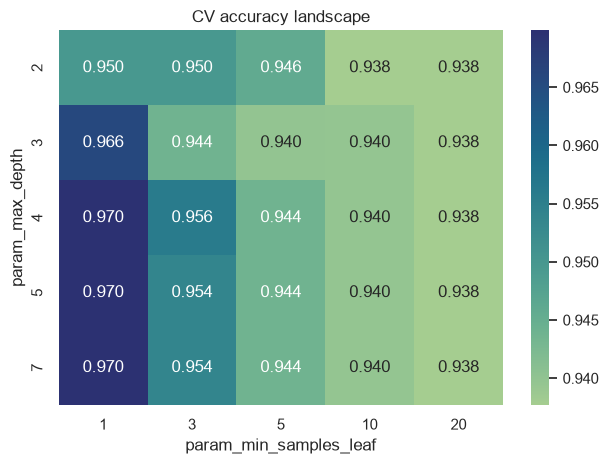

In [3]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {"max_depth": [2, 3, 4, 5, 7, None],
     "min_samples_leaf": [1, 3, 5, 10, 20],
     "criterion": ["gini", "entropy"]},
    cv=5, n_jobs=-1)
grid.fit(X_tr, y_tr)
best = grid.best_estimator_

print("best:", grid.best_params_, f"| CV {grid.best_score_:.4f}")
print(f"test accuracy: {accuracy_score(y_te, best.predict(X_te)):.4f}")

res = pd.DataFrame(grid.cv_results_)
pivot = res.pivot_table(index="param_max_depth", columns="param_min_samples_leaf",
                        values="mean_test_score")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="crest")
plt.title("CV accuracy landscape"); plt.tight_layout(); plt.show()

## 3. Feature importances - with a health warning

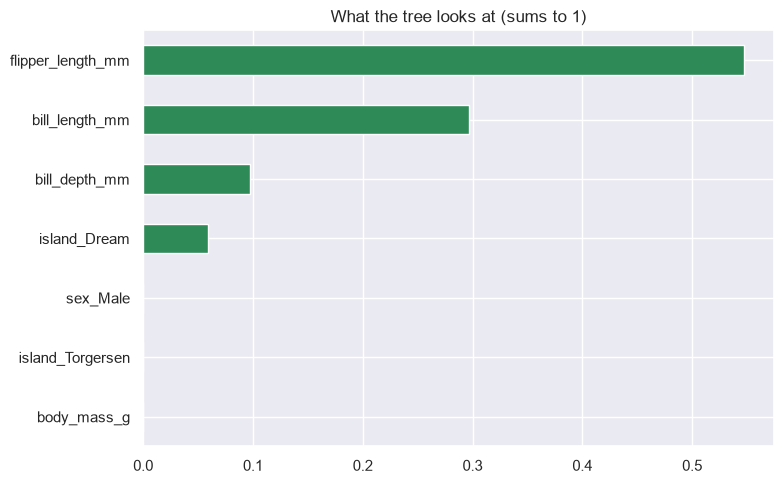

flipper_length_mm    0.547
bill_length_mm       0.297
bill_depth_mm        0.097
dtype: float64
⚠️ importances are biased toward high-cardinality/split-happy features;
   use permutation_importance for stakes-raising decisions.


In [4]:
imp = pd.Series(best.feature_importances_, index=X.columns).sort_values()
colors = ["seagreen" if v > 0 else "lightgray" for v in imp]
imp.plot(kind="barh", color=colors[-len(imp):], figsize=(8, 5))
plt.title("What the tree looks at (sums to 1)")
plt.tight_layout(); plt.show()

top3 = imp.nlargest(3)
print(top3.round(3))
print("⚠️ importances are biased toward high-cardinality/split-happy features;")
print("   use permutation_importance for stakes-raising decisions.")

## 4. Visualize the winning tree + cost-complexity path

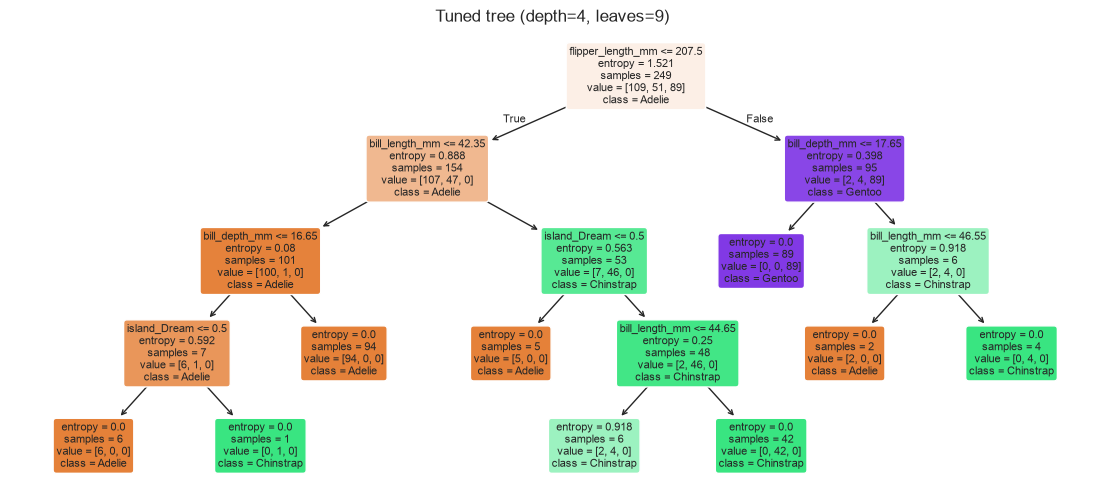

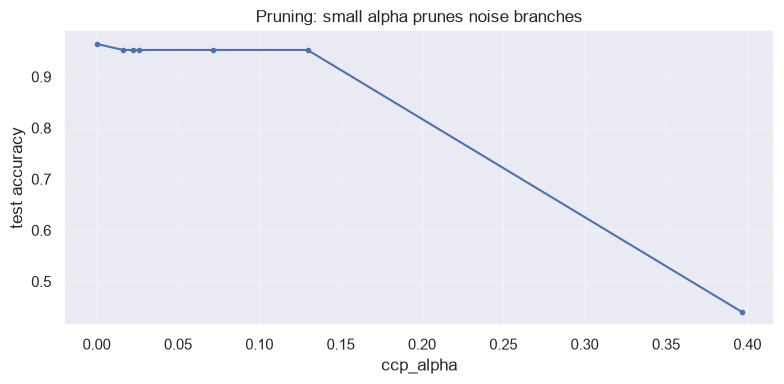

,Adelie,Chinstrap,Gentoo
Adelie,34,3,0
Chinstrap,0,17,0
Gentoo,2,0,28


In [5]:
plt.figure(figsize=(14, 6))
plot_tree(best, feature_names=X.columns, class_names=best.classes_,
          filled=True, rounded=True, fontsize=8)
plt.title(f"Tuned tree (depth={best.get_depth()}, leaves={best.get_n_leaves()})")
plt.show()

path = best.cost_complexity_pruning_path(X_tr, y_tr)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
alphas_used = ccp_alphas[:-1][:40]                 # candidate pruning strengths
test_scores = []
for a in alphas_used:                              # one small tree per alpha
    t = DecisionTreeClassifier(ccp_alpha=a, random_state=42).fit(X_tr, y_tr)
    test_scores.append(t.score(X_te, y_te))

plt.figure(figsize=(8, 4))
plt.plot(alphas_used, test_scores, "o-", ms=3)   # x = SAME sampled alphas as y
plt.xlabel("ccp_alpha"); plt.ylabel("test accuracy")
plt.title("Pruning: small alpha prunes noise branches")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

pd.DataFrame(confusion_matrix(y_te, best.predict(X_te)),
             index=best.classes_, columns=best.classes_)

## Summary & key takeaways

- Trees need NO scaling; they care about split ORDER not magnitudes.
- Tune depth/leaf-size together - the heatmap shows their interaction.
- Importances are indicative, not causal; verify with permutations.
- The pruning path gives a whole family of smaller trees - pick by CV.